# NER — ViSoBERT Token Classification (v2)

Single unified model for all 13 entity types.
- Data: per-file 70/15/15 split + augmented weak-class samples
- Imbalance: no-entity product_ner downsampled to ≤35%
- Loss: Focal Loss (γ=2) — focuses on hard/rare examples

In [1]:
!pip install transformers torch seqeval scikit-learn hf_xet --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json, os, random
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import classification_report, f1_score as seqeval_f1
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME   = 'uitnlp/visobert'
MAX_LENGTH   = 128
BATCH_SIZE   = 16
LR           = 2e-5
EPOCHS       = 20
PATIENCE     = 4
WARMUP_RATIO = 0.1
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

os.makedirs('results', exist_ok=True)

Device: cuda


In [4]:
# 13 entity types → 27 classes (O + B/I × 13)
ENTITY_TYPES = [
    'NAME', 'PHONE', 'ADDRESS', 'CITY',
    'PRODUCT_NAME', 'SHIP_DATE', 'SHIP_TIME', 'TYPE',
    'COMPLEXITY', 'QUANTITY', 'PRODUCT_COLOR',
    'MAX_BUDGET', 'MIN_BUDGET',
]
LABELS   = ['O'] + [f'{p}-{e}' for e in ENTITY_TYPES for p in ('B', 'I')]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)
print(f'Total labels: {NUM_LABELS}')
print(LABELS)

Total labels: 27
['O', 'B-NAME', 'I-NAME', 'B-PHONE', 'I-PHONE', 'B-ADDRESS', 'I-ADDRESS', 'B-CITY', 'I-CITY', 'B-PRODUCT_NAME', 'I-PRODUCT_NAME', 'B-SHIP_DATE', 'I-SHIP_DATE', 'B-SHIP_TIME', 'I-SHIP_TIME', 'B-TYPE', 'I-TYPE', 'B-COMPLEXITY', 'I-COMPLEXITY', 'B-QUANTITY', 'I-QUANTITY', 'B-PRODUCT_COLOR', 'I-PRODUCT_COLOR', 'B-MAX_BUDGET', 'I-MAX_BUDGET', 'B-MIN_BUDGET', 'I-MIN_BUDGET']


## 1. Data Loading — per-file split (Option B)

Split each source file independently at 70/15/15, then merge the three train sets,
three val sets, and three test sets. This ensures each entity type appears in all splits.

In [ ]:
DATA_DIR = Path('../ner_data')

def split_file(records, train_r=0.70, val_r=0.15, seed=SEED):
    idx = list(range(len(records)))
    random.Random(seed).shuffle(idx)
    n_tr = int(len(records) * train_r)
    n_va = int(len(records) * val_r)
    return (
        [records[i] for i in idx[:n_tr]],
        [records[i] for i in idx[n_tr:n_tr + n_va]],
        [records[i] for i in idx[n_tr + n_va:]],
    )

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def downsample_no_entity(records, max_ratio=0.35, seed=SEED):
    """Keep all entity samples; downsample no-entity to at most max_ratio of total."""
    with_ent = [r for r in records if r['entities']]
    no_ent   = [r for r in records if not r['entities']]
    max_keep = int(len(with_ent) * max_ratio / (1 - max_ratio))
    kept     = random.Random(seed).sample(no_ent, min(len(no_ent), max_keep))
    return with_ent + kept

# ── Load base files ────────────────────────────────────────────────────────────
product_records = load_json(DATA_DIR / 'product_ner.json')
info_records    = load_json(DATA_DIR / 'info_ner.json')
budget_records  = load_json(DATA_DIR / 'budget_ner.json')

# ── Load augmented files if they exist ────────────────────────────────────────
for aug_path, target in [
    (DATA_DIR / 'augmented_product_ner.json', 'product'),
    (DATA_DIR / 'augmented_info_ner.json',    'info'),
    (DATA_DIR / 'augmented_budget_ner.json',  'budget'),
]:
    if aug_path.exists():
        aug = load_json(aug_path)
        if target == 'product':
            product_records += aug
        elif target == 'info':
            info_records += aug
        elif target == 'budget':
            budget_records += aug
        print(f'Loaded {len(aug)} augmented {target}_ner samples')

# ── Downsample no-entity product_ner (was 52% → ≤35%) ─────────────────────────
before = len(product_records)
product_records = downsample_no_entity(product_records)
no_ent_pct = sum(1 for r in product_records if not r['entities']) / len(product_records) * 100
print(f'product_ner: {before} → {len(product_records)} after downsampling ({no_ent_pct:.0f}% no-entity)')

# ── Per-file split then merge ──────────────────────────────────────────────────
all_train, all_val, all_test = [], [], []
for fname, records in [('info_ner', info_records),
                        ('product_ner', product_records),
                        ('budget_ner', budget_records)]:
    tr, va, te = split_file(records)
    all_train += tr
    all_val   += va
    all_test  += te
    print(f'{fname}: {len(records):>4} total  →  {len(tr):>4} train / {len(va):>3} val / {len(te):>3} test')

random.shuffle(all_train)
print(f'\nCombined: {len(all_train)} train / {len(all_val)} val / {len(all_test)} test')

## 2. Tokenisation + BIO Alignment

Character-level spans (start, end) are mapped to subword token labels.
Only the **first subword** of each word receives a label — continuation subwords
get `-100` and are ignored by the loss.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(record):
    text     = record['text']
    entities = sorted(record.get('entities', []), key=lambda e: e['start'])

    enc = tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,
        return_offsets_mapping=True,
    )
    offset_mapping = enc['offset_mapping']
    word_ids       = enc.word_ids()

    labels, prev_word_id = [], None
    for offset, wid in zip(offset_mapping, word_ids):
        if wid is None:                  # [CLS] / [SEP]
            labels.append(-100)
        elif wid == prev_word_id:        # continuation subword
            labels.append(-100)
        else:
            tok_s, tok_e = offset
            tag = 'O'
            for ent in entities:
                if tok_s >= ent['start'] and tok_e <= ent['end']:
                    prefix = 'B' if tok_s == ent['start'] else 'I'
                    tag    = f"{prefix}-{ent['label']}"
                    break
            labels.append(label2id.get(tag, label2id['O']))
        prev_word_id = wid

    return {
        'input_ids'     : enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels'        : labels,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

In [7]:
ENTITY_TYPES = [
    'NAME', 'PHONE', 'ADDRESS', 'CITY',
    'PRODUCT_NAME', 'SHIP_DATE', 'SHIP_TIME', 'TYPE',
    'COMPLEXITY', 'QUANTITY', 'PRODUCT_COLOR',
    'MAX_BUDGET', 'MIN_BUDGET',
]
LABELS   = ['O'] + [f'{p}-{e}' for e in ENTITY_TYPES for p in ('B', 'I')]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}

# Smoke test on first training sample with entities
sample_rec = next(r for r in all_train if r['entities'])
sample     = tokenize_and_align(sample_rec)
tokens     = tokenizer.convert_ids_to_tokens(sample['input_ids'])
print(f'Text: {sample_rec["text"]!r}\n')
print(f'{"Token":<20} Label')
for tok, lab in zip(tokens, sample['labels']):
    if lab != -100:
        print(f'  {tok:<20} {id2label[lab]}')


Text: 'Shop có ảnh bộ LEGO Haunted House 10273 không?'

Token                Label
  ▁Shop                O
  ▁có                  O
  ▁ảnh                 O
  ▁bộ                  O
  ▁L                   B-PRODUCT_NAME
  ▁H                   I-PRODUCT_NAME
  ▁H                   I-PRODUCT_NAME
  ▁10                  I-PRODUCT_NAME
  ▁kh                  O


## 3. Dataset + DataLoader

In [ ]:
def maybe_lowercase(record, p=0.3):
    """Randomly lowercase the text of a record (30% chance per call).

    .lower() preserves character count for Vietnamese, so char offsets stay valid.
    """
    if random.random() < p:
        return {**record, 'text': record['text'].lower()}
    return record

class NERDataset(Dataset):
    def __init__(self, records, augment=False):
        self.records = records
        self.augment = augment   # True only for train split
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        if self.augment:
            rec = maybe_lowercase(rec)   # fresh roll each epoch → variation across epochs
        return tokenize_and_align(rec)

def collate_fn(batch):
    max_len = max(len(s['input_ids']) for s in batch)
    input_ids, masks, labels = [], [], []
    for s in batch:
        pad = max_len - len(s['input_ids'])
        input_ids.append(s['input_ids'] + [tokenizer.pad_token_id] * pad)
        masks.append(s['attention_mask'] + [0] * pad)
        labels.append(s['labels'] + [-100] * pad)
    return {
        'input_ids'     : torch.tensor(input_ids),
        'attention_mask': torch.tensor(masks),
        'labels'        : torch.tensor(labels),
    }

train_ds = NERDataset(all_train, augment=True)    # random lowercase 30% per epoch
val_ds   = NERDataset(all_val,   augment=False)   # original text — clean eval
test_ds  = NERDataset(all_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')
print(f'Case augmentation: ON (p=0.30) for train | OFF for val/test')

## 4. Class Weights

`O` dominates (most tokens are outside any entity). Weighted CrossEntropy
downweights `O` so the model is penalised more for missing real entities.

In [9]:
label_counts = Counter()
for rec in all_train:
    for lab in tokenize_and_align(rec)['labels']:
        if lab != -100:
            label_counts[lab] += 1

total   = sum(label_counts.values())
weights = torch.ones(NUM_LABELS)
for lab_id, cnt in label_counts.items():
    weights[lab_id] = total / (NUM_LABELS * cnt)

# Cap O weight — we still need the model to predict O correctly
O_IDX = label2id['O']
weights[O_IDX] = min(weights[O_IDX].item(), 0.5)
weights = weights.to(DEVICE)

print('O tag weight :',  round(weights[O_IDX].item(), 4))
print('Top-5 highest weights:')
for i in sorted(range(NUM_LABELS), key=lambda i: -weights[i].item())[:5]:
    print(f'  {LABELS[i]:<25} {weights[i].item():.3f}')

O tag weight : 0.0497
Top-5 highest weights:
  I-PHONE                   121.389
  I-PRODUCT_COLOR           121.389
  I-CITY                    69.365
  B-PRODUCT_COLOR           53.951
  B-MIN_BUDGET              48.556


## 5. Model Setup

In [ ]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy/frequent examples, focuses on hard/rare ones.
    γ=2 is the standard default; higher γ = more focus on hard examples.
    """
    def __init__(self, weight=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.weight       = weight
        self.gamma        = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight,
                               ignore_index=self.ignore_index, reduction='none')
        pt   = torch.exp(-ce)                       # predicted probability of correct class
        loss = ((1 - pt) ** self.gamma) * ce        # down-weight easy examples
        mask = targets != self.ignore_index
        return loss[mask].mean()


model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion    = FocalLoss(weight=weights, gamma=2.0, ignore_index=-100)

print(f'Parameters : {sum(p.numel() for p in model.parameters()):,}')
print(f'Train steps: {total_steps}  |  Warmup: {warmup_steps}')
print(f'Loss       : FocalLoss (γ=2.0) + class weights')

## 6. Training

In [11]:
def predict_tags(loader):
    """Return (all_preds, all_trues) as lists of tag-string sequences."""
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE),
            ).logits
            preds  = logits.argmax(-1).cpu()
            labels = batch['labels']
            for pred_row, true_row in zip(preds, labels):
                p_seq, t_seq = [], []
                for p, t in zip(pred_row.tolist(), true_row.tolist()):
                    if t != -100:
                        p_seq.append(id2label[p])
                        t_seq.append(id2label[t])
                all_preds.append(p_seq)
                all_trues.append(t_seq)
    return all_preds, all_trues

def evaluate_f1(loader):
    preds, trues = predict_tags(loader)
    return seqeval_f1(trues, preds, average='micro', zero_division=0)

In [12]:
train_losses, val_f1s = [], []
best_val_f1, best_epoch, patience_ctr = 0.0, 0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        logits = model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
        ).logits
        loss = criterion(logits.view(-1, NUM_LABELS), batch['labels'].to(DEVICE).view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_f1(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1, best_epoch, patience_ctr = val_f1, epoch, 0
        torch.save(model.state_dict(), 'results/ner_best_model.pt')
    else:
        patience_ctr += 1

    flag = ' *' if improved else ''
    print(f'Epoch {epoch:>2}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Micro-F1: {val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (best: epoch {best_epoch})')
        break

print(f'\nBest Val Micro-F1: {best_val_f1:.4f} at epoch {best_epoch}')

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Epoch  1/20 | Loss: 3.1442 | Val Micro-F1: 0.0542 *
Epoch  2/20 | Loss: 1.8305 | Val Micro-F1: 0.1956 *
Epoch  3/20 | Loss: 0.7768 | Val Micro-F1: 0.3574 *
Epoch  4/20 | Loss: 0.3566 | Val Micro-F1: 0.5014 *
Epoch  5/20 | Loss: 0.1738 | Val Micro-F1: 0.5723 *
Epoch  6/20 | Loss: 0.1069 | Val Micro-F1: 0.5781 *
Epoch  7/20 | Loss: 0.0754 | Val Micro-F1: 0.6370 *
Epoch  8/20 | Loss: 0.0458 | Val Micro-F1: 0.6524 *
Epoch  9/20 | Loss: 0.0345 | Val Micro-F1: 0.6759 *
Epoch 10/20 | Loss: 0.0306 | Val Micro-F1: 0.6960 *
Epoch 11/20 | Loss: 0.0223 | Val Micro-F1: 0.6866
Epoch 12/20 | Loss: 0.0180 | Val Micro-F1: 0.6883
Epoch 13/20 | Loss: 0.0151 | Val Micro-F1: 0.7021 *
Epoch 14/20 | Loss: 0.0209 | Val Micro-F1: 0.7063 *
Epoch 15/20 | Loss: 0.0132 | Val Micro-F1: 0.7156 *
Epoch 16/20 | Loss: 0.0130 | Val Micro-F1: 0.7140
Epoch 17/20 | Loss: 0.0110 | Val Micro-F1: 0.7117
Epoch 18/20 | Loss: 0.0100 | Val Micro-F1: 0.7153
Epoch 19/20 | Loss: 0.0087 | Val Micro-F1: 0.7169 *
Epoch 20/20 | Loss: 0.

## 7. Training Curves

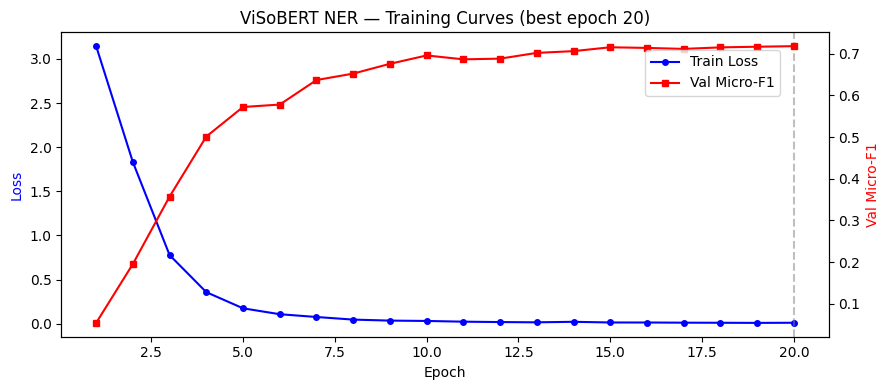

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2      = ax1.twinx()
epochs_x = list(range(1, len(train_losses) + 1))

ax1.plot(epochs_x, train_losses, 'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_x, val_f1s,     'r-s', markersize=4, label='Val Micro-F1')
ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss',        color='b')
ax2.set_ylabel('Val Micro-F1', color='r')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title(f'ViSoBERT NER — Training Curves (best epoch {best_epoch})')
plt.tight_layout()
plt.savefig('results/ner_training_curves.png', dpi=150)
plt.show()

## 8. Test Evaluation (entity-level F1 via seqeval)

In [14]:
model.load_state_dict(torch.load('results/ner_best_model.pt', map_location=DEVICE))
test_preds, test_trues = predict_tags(test_loader)

report = classification_report(test_trues, test_preds, digits=4, zero_division=0)
print(report)

with open('results/ner_test_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

               precision    recall  f1-score   support

      ADDRESS     0.7200    0.7500    0.7347        24
         CITY     0.5000    1.0000    0.6667         2
   COMPLEXITY     0.2632    0.4545    0.3333        11
   MAX_BUDGET     0.8667    0.8667    0.8667        15
   MIN_BUDGET     0.5714    0.8000    0.6667         5
         NAME     0.9500    0.9500    0.9500        20
        PHONE     1.0000    1.0000    1.0000        22
PRODUCT_COLOR     0.5000    0.6000    0.5455         5
 PRODUCT_NAME     0.6703    0.7922    0.7262        77
     QUANTITY     0.6667    0.6667    0.6667         3
    SHIP_DATE     0.6842    0.7222    0.7027        18
    SHIP_TIME     0.7647    0.9286    0.8387        14
         TYPE     0.3077    0.5714    0.4000         7

    micro avg     0.6858    0.8027    0.7397       223
    macro avg     0.6511    0.7771    0.6998       223
 weighted avg     0.7145    0.8027    0.7525       223



## 9. Save Model

In [15]:
os.makedirs('results/ner_model', exist_ok=True)
model.save_pretrained('results/ner_model')
tokenizer.save_pretrained('results/ner_model')
print('Saved to results/ner_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to results/ner_model/


## 10. Inference Demo

In [3]:
def predict_ner(text: str) -> list[dict]:
    model.eval()
    enc = tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        return_offsets_mapping=True,
        return_tensors='pt',
    )
    offset_mapping = enc.pop('offset_mapping')[0].tolist()
    word_ids       = tokenizer(text, max_length=MAX_LENGTH, truncation=True).word_ids()
    enc            = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        preds = model(**enc).logits[0].argmax(-1).tolist()

    entities = []
    cur_label, cur_start, cur_end = None, 0, 0

    for pred, offset, wid in zip(preds, offset_mapping, word_ids):
        if wid is None:
            continue
        tok_s, tok_e = offset
        if tok_s == tok_e == 0:
            continue
        tag = id2label[pred]
        if tag == 'O':
            if cur_label:
                entities.append({'label': cur_label, 'start': cur_start, 'end': cur_end,
                                  'text': text[cur_start:cur_end]})
            cur_label = None
        elif tag.startswith('B-'):
            if cur_label:
                entities.append({'label': cur_label, 'start': cur_start, 'end': cur_end,
                                  'text': text[cur_start:cur_end]})
            cur_label, cur_start, cur_end = tag[2:], tok_s, tok_e
        elif tag.startswith('I-'):
            if cur_label == tag[2:]:
                cur_end = tok_e
            else:  # unexpected I without matching B
                if cur_label:
                    entities.append({'label': cur_label, 'start': cur_start, 'end': cur_end,
                                      'text': text[cur_start:cur_end]})
                cur_label, cur_start, cur_end = tag[2:], tok_s, tok_e

    if cur_label:
        entities.append({'label': cur_label, 'start': cur_start, 'end': cur_end,
                          'text': text[cur_start:cur_end]})
    return entities

In [18]:
test_cases = [
    'Nguyên Thảo\n0912495077\nK45/10B Dũng Sĩ Thanh Khê',
    'bạn có bộ nào tầm 200k không ạ',
    'mình muốn đặt bộ lego city, ship ngày mai nhé',
    'tên: Phạm Thành\nsdt: 0949913458\ndchi: 46 Sơn Hải Đồ Sơn Hải Phòng',
    'em ở hn ạ',
    'cho em đặt 1 bộ mẹc f1 về Cát Linh với ạ'
]
for text in test_cases:
    ents = predict_ner(text)
    print(f'Input : {text!r}')
    if ents:
        for e in ents:
            print(f'  {e["label"]:<15} {e["text"]!r}')
    else:
        print('  (no entities)')
    print()

Input : 'Nguyên Thảo\n0912495077\nK45/10B Dũng Sĩ Thanh Khê'
  NAME            'Nguyên Thảo'
  PHONE           '09'
  PHONE           '12495077'
  ADDRESS         'K'
  ADDRESS         '45'
  ADDRESS         '/10B Dũng Sĩ Thanh Khê'

Input : 'bạn có bộ nào tầm 200k không ạ'
  MAX_BUDGET      '2'
  MAX_BUDGET      '00k'

Input : 'mình muốn đặt bộ lego city, ship ngày mai nhé'
  PRODUCT_NAME    'bộ'
  PRODUCT_NAME    'lego city'
  SHIP_DATE       'ng'
  SHIP_DATE       'ày mai'

Input : 'tên: Phạm Thành\nsdt: 0949913458\ndchi: 46 Sơn Hải Đồ Sơn Hải Phòng'
  NAME            'Phạm Thành'
  PHONE           ':'
  PHONE           '09'
  PHONE           '49'
  PHONE           '91'
  PHONE           '34'
  ADDRESS         ':'
  ADDRESS         '46 Sơn Hải Đồ Sơn Hải Phòng'

Input : 'em ở hn ạ'
  CITY            'hn'

Input : 'cho em đặt 1 bộ mẹc f1 về Cát Linh với ạ'
  QUANTITY        '1 bộ'
  PRODUCT_NAME    'm'
  PRODUCT_NAME    'ẹc f1 về'
  ADDRESS         'Cát Linh'



In [5]:
import torch

def extract_entities_from_text(text, model, tokenizer, id2label, device='cuda'):
    model.eval()
    
    # 1. Tokenize with offset mapping to link tokens back to original string indexes
    inputs = tokenizer(
        text,
        return_offsets_mapping=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    offset_mapping = inputs['offset_mapping'][0].tolist()
    word_ids = inputs.word_ids(batch_index=0)
    
    # 2. Get model predictions
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(-1)[0].cpu().tolist()
        
    extracted_chunks = []
    current_entity = None
    
    # 3. Iterate through tokens and reconstruct chunks based on character boundary mappings
    for idx, (pred_id, offset, word_id) in enumerate(zip(predictions, offset_mapping, word_ids)):
        if word_id is None: # Ignore special tokens [CLS], [SEP]
            continue
            
        tag = id2label[pred_id]
        start_char, end_char = offset
        
        if tag == 'O':
            if current_entity:
                extracted_chunks.append(current_entity)
                current_entity = None
            continue
            
        prefix, entity_type = tag.split('-')
        
        # Determine if this token belongs to the active running entity sequence
        if current_entity and current_entity['type'] == entity_type:
            # Update end character reference to swallow subword continuations or adjacent entities
            current_entity['end'] = end_char
        else:
            # If there was a previous entity type sequence running, save it first
            if current_entity:
                extracted_chunks.append(current_entity)
            
            # Start a brand new entity sequence tracking group
            current_entity = {
                'type': entity_type,
                'start': start_char,
                'end': end_char
            }
            
    if current_entity:
        extracted_chunks.append(current_entity)
        
    # 4. Map the boundary spans back to the raw source text strings and clean up syntax symbols
    final_results = {}
    for ent in extracted_chunks:
        raw_value = text[ent['start']:ent['end']].strip()
        
        # Post-processing cleanup: strip syntax colons or dangling prefixes/suffixes often seen in chat contexts
        cleaned_value = raw_value.lstrip(':').strip()
        
        if not cleaned_value:
            continue
            
        # Group by type into lists to accommodate multiples (like multiple items or multi-line addresses)
        if ent['type'] not in final_results:
            final_results[ent['type']] = []
        
        if cleaned_value not in final_results[ent['type']]:
            final_results[ent['type']].append(cleaned_value)
            
    return final_results

In [ ]:
test_input = 'tìm cho em sản phẩm khoảng tầm 8 triệu nhé shop'

entities = extract_entities_from_text(
    text=test_input,
    model=model,
    tokenizer=tokenizer,
    id2label=id2label,
    device=DEVICE
)

for entity_type, values in entities.items():
    for val in values:
        print(f"{entity_type:<15} '{val}'")

In [1]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained('uitnlp/visobert')          # từ HF Hub
model     = AutoModelForTokenClassification.from_pretrained('results/ner_model')  # local weights
model.to(DEVICE)
model.eval()

id2label = model.config.id2label


c:\Users\Huawei\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5390.16it/s]


In [6]:
test_cases = [
    'Nguyên Thảo\n0912495077\nK45/10B Dũng Sĩ Thanh Khê',
    'bạn có bộ nào tầm 200k không ạ',
    'mình muốn đặt bộ lego city, ship ngày mai nhé',
    'tên: Phạm Thành\nsdt: 0949913458\ndchi: 46 Sơn Hải Đồ Sơn Hải Phòng',
    'em ở hn ạ',
    'cho em đặt 1 bộ mẹc f1 về Cát Linh với ạ'
]
for text in test_cases:
    ents = predict_ner(text)
    print(f'Input : {text!r}')
    if ents:
        for e in ents:
            print(f'  {e["label"]:<15} {e["text"]!r}')
    else:
        print('  (no entities)')
    print()

NameError: name 'MAX_LENGTH' is not defined